# 04 — NDVI Composite (Google Earth Engine → Drive Export)

Extract a multi-year Sentinel-2 NDVI composite for each coffee cell.
One best image per month (2017–2025) is selected; the per-pixel median
across those ~96 images gives a single robust greenness value per cell.

Coffee is evergreen — NDVI is stable year-round, so one median value
captures the farm's characteristic canopy density without seasonal noise.

**Feature produced:**
- `ndvi_median` — median greenness across all clear observations 2017–2025

## Workflow
1. **Export**: Submit one GEE task → Drive folder `ee_ndvi_composite/`
2. **Download**: Move CSV → `../data/ndvi/ndvi_composite.csv`
3. **Features**: Derive per-cell feature → `../data/plot_ndvi_features.pkl`

**Prerequisites:** `earthengine authenticate` in terminal.

In [1]:
import ee
import geopandas as gpd
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
NDVI_DIR     = '../data/ndvi/plots'
os.makedirs(NDVI_DIR, exist_ok=True)

COMPOSITE_FILE = os.path.join(NDVI_DIR, 'ndvi_composite_2017_2025.csv')
FEAT_PICKLE    = '../data/plot_ndvi_features.pkl'

downloaded = os.path.isfile(COMPOSITE_FILE)
if downloaded:
    print(f'Composite CSV found — skipping GEE export.')
else:
    print('Composite CSV not found — will run GEE export.')

/home/simonhans/anaconda3/lib/python3.7/site-packages/google/auth/crypt/_cryptography_rsa.py:22: CryptographyDeprecationWarning: Python 3.7 is no longer supported by the Python core team and support for it is deprecated in cryptography. The next release of cryptography will remove support for Python 3.7.
  import cryptography.exceptions
/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


Composite CSV found — skipping GEE export.


In [2]:
# ── Google Earth Engine authentication ───────────────────────────────────────
# Run this cell once whenever your credentials expire.
# It will open a browser tab — paste the authorization code back here.
import ee
ee.Authenticate()
ee.Initialize(project='ee-simonhansedasi')
print('GEE authenticated and initialized.')

GEE authenticated and initialized.


In [3]:
if not downloaded:
    print('GEE initialized.')

    # Load hex grid — filter to coffee cells only (label == 1)
    grid = pd.read_pickle('../data/polygons/kona_grid.pkl')  # EPSG:4326
    grid_export = grid[grid['label'] == 1].copy()
    print(f'Total grid cells: {len(grid):,}  →  exporting {len(grid_export):,} coffee cells (label=1)')

    from shapely.geometry import Polygon, MultiPolygon

    def shapely_to_ee_feature(poly, plot_id):
        if poly.geom_type == 'Polygon':
            return ee.Feature(
                ee.Geometry.Polygon(list(poly.exterior.coords)),
                {'plot_id': plot_id}
            )
        elif poly.geom_type == 'MultiPolygon':
            p = list(poly.geoms)[0]
            return ee.Feature(
                ee.Geometry.Polygon(list(p.exterior.coords)),
                {'plot_id': plot_id}
            )

    ee_features = []
    for _, row in tqdm(grid_export.iterrows(), total=len(grid_export), desc='Building EE features'):
        feat = shapely_to_ee_feature(row.geometry, int(row['plot_id']))
        ee_features.append(feat)

    hex_fc = ee.FeatureCollection(ee_features)
    print(f'EE FeatureCollection built: {len(ee_features)} features')
else:
    print('Skipping GEE setup — composite CSV already downloaded.')

Skipping GEE setup — composite CSV already downloaded.


In [4]:
if not downloaded:
    def mask_clouds_scl(image):
        scl = image.select('SCL')
        clear = (scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10)))
        return image.updateMask(clear)

    def add_ndvi(image):
        return image.addBands(
            image.normalizedDifference(['B8', 'B4']).rename('ndvi')
        )

    base = (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(hex_fc.geometry())
        .filterDate('2017-03-28', '2025-12-31')
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 50))
        .map(mask_clouds_scl)
        .map(add_ndvi)
        .select('ndvi')
    )

    # One best image per month — reduces 1548 images to ~96.
    # GEE median then holds 96 images in memory instead of 1548.
    def best_of_month(ym):
        ym   = ee.List(ym)
        y, m = ee.Number(ym.get(0)), ee.Number(ym.get(1))
        return (base
                .filter(ee.Filter.calendarRange(y, y, 'year'))
                .filter(ee.Filter.calendarRange(m, m, 'month'))
                .sort('CLOUDY_PIXEL_PERCENTAGE')
                .first())

    year_months = ee.List([
        [y, m]
        for y in range(2017, 2026)
        for m in range(1, 13)
    ])

    monthly_best = ee.ImageCollection(year_months.map(best_of_month).removeAll([None]))
    print(f'Monthly-best collection: {monthly_best.size().getInfo()} images')

    composite = monthly_best.median().unmask(-9999)

    centroid_fc = hex_fc.map(
        lambda f: ee.Feature(
            f.geometry().centroid(maxError=100),
            {'plot_id': f.get('plot_id')}
        )
    )

    # tileScale=16 processes in smaller memory tiles
    fc = composite.sampleRegions(
        collection=centroid_fc,
        scale=10,
        geometries=False,
        tileScale=16,
    )

    print('Composite + sample plan defined.')
else:
    print('Skipping — composite CSV already downloaded.')

Skipping — composite CSV already downloaded.


In [5]:
if not downloaded:
    description = 'ndvi_composite_2017_2025'

    task = ee.batch.Export.table.toDrive(
        collection=fc,
        description=description,
        folder='ee_ndvi_composite',
        fileFormat='CSV',
    )
    task.start()
    print(f'Task submitted: {description}')
    print(f'Download → ee_ndvi_composite/ → {COMPOSITE_FILE}')
else:
    print('Already exported.')

Already exported.


In [6]:
# ── Check GEE task status ─────────────────────────────────────────────────────
for t in ee.batch.Task.list():
    if 'ndvi_composite' in t.config.get('description', t.id):
        print(f"{t.config.get('description', t.id):55s}  {t.state}")

ndvi_composite_2017_2025                                 COMPLETED
ndvi_composite_2017_2025                                 FAILED
ndvi_composite_2017_2025                                 FAILED
ndvi_composite_2017_2025                                 CANCELLED
ndvi_composite_2017_2025                                 CANCELLED
ndvi_composite_2017_2025                                 CANCELLED


In [7]:
# ── Live task monitor ─────────────────────────────────────────────────────────
import time
from IPython.display import clear_output

POLL_INTERVAL = 30

while True:
    clear_output(wait=True)
    now = time.time()
    tasks = [t for t in ee.batch.Task.list()
             if 'ndvi_composite' in t.config.get('description', '')]

    if not tasks:
        print('No ndvi_ts task found.')
        break

    t = tasks[0]
    status = t.status()
    elapsed_str = ''
    start_ms = status.get('start_timestamp_ms')
    if start_ms:
        end_ms = status.get('update_timestamp_ms') or int(now * 1000)
        elapsed_str = f'  {(end_ms - start_ms) / 60000:.1f} min'

    print(f'=== GEE NDVI monitor  [{time.strftime("%H:%M:%S")}] ===')
    print(f'  {t.config.get("description", t.id)}  →  {t.state}{elapsed_str}')

    if t.state in ('COMPLETED', 'FAILED'):
        if t.state == 'FAILED':
            print('  ERROR:', status.get('error_message', 'unknown'))
        else:
            print('  Done — download from Drive → ee_ndvi_ts/')
        break

    print(f'\n  (refreshing in {POLL_INTERVAL}s)')
    time.sleep(POLL_INTERVAL)

=== GEE NDVI monitor  [11:49:34] ===
  ndvi_composite_2017_2025  →  COMPLETED  0.2 min
  Done — download from Drive → ee_ndvi_ts/


In [8]:
# ── Load composite CSV ────────────────────────────────────────────────────────
df = pd.read_csv(COMPOSITE_FILE)
df['plot_id'] = df['plot_id'].astype(int)
df = df.rename(columns={'ndvi': 'ndvi_median'})
df['ndvi_median'] = pd.to_numeric(df['ndvi_median'], errors='coerce')
df['ndvi_median'] = df['ndvi_median'].replace(-9999, float('nan'))

print(f'Loaded: {len(df):,} cells')
print(f'Valid NDVI: {df["ndvi_median"].notna().sum():,} ({100*df["ndvi_median"].notna().mean():.1f} %)')
print(f'Columns: {list(df.columns)}')
df.head()

Loaded: 471 cells
Valid NDVI: 471 (100.0 %)
Columns: ['system:index', 'ndvi_median', 'plot_id', '.geo']


,system:index,ndvi_median,plot_id,.geo
0,0_0,0.749277,211,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,1_0,0.602482,212,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,2_0,0.680291,213,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,3_0,0.492683,214,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,4_0,0.622430,656,"{""type"":""MultiPoint"",""coordinates"":[]}"


In [9]:
# ── Save features ─────────────────────────────────────────────────────────────
ndvi_features = df[['plot_id', 'ndvi_median']].dropna().reset_index(drop=True)
print(f'{len(ndvi_features):,} cells with valid NDVI')

ndvi_features.to_pickle(FEAT_PICKLE)
print(f'Saved {FEAT_PICKLE}')
ndvi_features.describe().round(3)

471 cells with valid NDVI
Saved ../data/plot_ndvi_features.pkl


,plot_id,ndvi_median
count,471.000,471.000
mean,6208.699,0.758
std,2174.913,0.099
min,211.000,0.126
25%,5405.500,0.707
50%,6463.000,0.772
75%,7843.500,0.829
max,10043.000,0.923


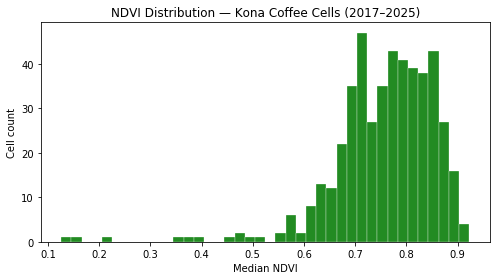

In [10]:
# ── Distribution of NDVI across coffee cells ─────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ndvi_features['ndvi_median'], bins=40,
        color='forestgreen', edgecolor='white', linewidth=0.3)
ax.set_xlabel('Median NDVI')
ax.set_ylabel('Cell count')
ax.set_title('NDVI Distribution — Kona Coffee Cells (2017–2025)')
plt.tight_layout()
plt.savefig('../img/04_ndvi_distribution.png', dpi=150)
plt.show()

In [11]:
import warnings
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
warnings.filterwarnings('ignore', message='Geometry is in a geographic CRS')

SPLIT_LON = -155.7279
BG = '#111111'

def clip_cmap(name, lo=0.0, hi=0.9):
    """Clip colormap to avoid the near-white tip at the bright end."""
    base = cm.get_cmap(name)
    return LinearSegmentedColormap.from_list(
        f'{name}_clip', base(np.linspace(lo, hi, 256))
    )

def plot_regions(gdf, col, title, cmap, fname):
    cx = gdf.geometry.centroid.x
    cy = gdf.geometry.centroid.y

    kona = gdf[cx < SPLIT_LON]
    kau  = gdf[cx >= SPLIT_LON]

    kona_cy = cy[kona.index]
    lat_min, lat_max = kona_cy.min(), kona_cy.max()
    cut1 = lat_min + (lat_max - lat_min) / 3
    cut2 = lat_min + 2 * (lat_max - lat_min) / 3

    kona_n = kona[kona_cy >= cut2]
    kona_m = kona[(kona_cy >= cut1) & (kona_cy < cut2)]
    kona_s = kona[kona_cy < cut1]

    ab = kau.total_bounds
    span_w = (ab[2] - ab[0]) * 1.15
    span_h = (ab[3] - ab[1]) * 1.15

    def centroid(region):
        b = region.total_bounds
        return (b[0]+b[2])/2, (b[1]+b[3])/2

    panels = [
        (kona_n, 'Kona N'),
        (kona_m, 'Kona Central'),
        (kona_s, 'Kona S'),
        (kau,    "Ka\u02BBu"),
    ]

    vmin = gdf[col].quantile(0.02)
    vmax = gdf[col].quantile(0.98)

    fig, axes = plt.subplots(2, 2, figsize=(11, 10),
                             gridspec_kw={'hspace': 0.06, 'wspace': 0.04})
    fig.patch.set_facecolor(BG)

    for ax, (region, label) in zip(axes.flat, panels):
        rx, ry = centroid(region)
        ax.set_facecolor(BG)
        region.plot(ax=ax, column=col, cmap=cmap,
                    vmin=vmin, vmax=vmax,
                    legend=False, edgecolor='none', alpha=0.9)
        ax.set_xlim(rx - span_w/2, rx + span_w/2)
        ax.set_ylim(ry - span_h/2, ry + span_h/2)
        ax.set_title(label, fontsize=12, pad=5, color='white')
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor('#333333')

    sm = plt.cm.ScalarMappable(cmap=cmap,
                               norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, shrink=0.6, pad=0.02, aspect=25)
    cbar.set_ticks([vmin, vmax])
    cbar.set_ticklabels(['min', 'max'])
    cbar.ax.yaxis.set_tick_params(color='white', labelcolor='white', labelsize=10)
    cbar.outline.set_edgecolor('#333333')

    fig.suptitle(title, fontsize=14, color='white', y=1.01)
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor=BG)
    plt.show()

import geopandas as gpd
grid     = gpd.read_pickle('../data/polygons/kona_grid.pkl')
gdf_ndvi = grid.merge(ndvi_features, on='plot_id')
plot_regions(gdf_ndvi, 'ndvi_median',
             'Median NDVI (2017–2025)', clip_cmap('viridis', lo=0.2),
             '../img/04_ndvi_features.png')


AttributeError: module 'geopandas' has no attribute 'read_pickle'